In [1]:
import torch
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Hyperparams
graph = [ [0, 1], [1, 2], [2, 3], [3, 0], [0, 4], [1, 4], [2, 4], [3, 4] ]
p1 = {
    '1_learning_rate': 0.0025, '1_hidden_size': 48, '1_dropout': 0.225,
    '1_quantum' : False, '1_num_head': 4, '1_Attention_N' : 2, '1_num_transf': 2, '1_mlp_size': 5, '1_patch_size': 4, '1_weight_decay': 1e-7, '1_attention_selection': 'none', 
    '1_selection_amount': 49, '1_RD': 1, '1_connectivity' : graph ,'1_entangle_method' : 'CNOT', '1_special_cls' : 'none', '1_paralel': 1, '1_patience': -1, 
    '1_scheduler_factor': 0.985, '1_q_stride': 1, '1_ancilla' : 1, '1_channels_out' : [4, 0, 1, 2, 3], '1_augmentation_prob' : 0, '1_val_train_pond' : 1,
    '1_flatten_extra_channels' : False, '1_quanv_kernel_size' : 2
}

p2 = {
    'learning_rate': 0.0025, 'hidden_size': 48, 'dropout': 0.225,
    'quantum' : False, 'num_head': 4, 'Attention_N' : 2, 'num_transf': 2, 'mlp_size': 5, 'patch_size': 4, 'weight_decay': 1e-7, 'attention_selection': 'filter',
    'selection_amount': 49, 'RD': 1, 'special_cls' : 'none', 'paralel': 2, 'patience': -1, 'scheduler_factor': 0.985, 'q_stride': 1, 'augmentation_prob' : 0,
    'val_train_pond' : 1, 'len_channels_scaler' : 2
}

exp_config = {
    'channels_last'         : False,         # True if last dimension of datasets tensors match channels dimension
    'repeat_selector'       : False,         # True to train autoencoder each time for more variability
    'send_telegram'         : True,
    'num_experiments'       : 1,
    'num_classes'           : 7,
    'trained_selector_once' : False,
    'pixels'                : 28,
    'experiment_name'       : 'Resolution224/16x16patches/kernel3x3 Selformer',
    'experiment_id'         : 'final_stand/3x3/dropout_channels/extra_patches/4x4patches/concatenate_original',
    'variant'               : 'selformer',
    'B'                     : 256,
    'special_batch_for_data': False,
    'rewind_channels'       : False,
    'N1'                    : 1,
    'N2'                    : 30,
    'q_config'              : {'patchwise','none'},
    'device'                : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
    'second_at_a_time'      : False,
    'augmenting'            : False,
    'concatenate_original'  : True
}

# Helper functions: 
def make_dropout(drop):
    return {'embedding_attn': drop, 'after_attn': drop, 'feedforward': drop, 'embedding_pos': drop}

visualizing_n = 3
concatenate_originals = True

print(f"Using device: {exp_config['device']}")

Using device: cuda:0


Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Loaded MedMNIST dataset 'dermamnist' with image size 28x28 and 3 channels.
Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a FeedForward Module with Quantum-setting: False
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a FeedForward Module with Quantum-setting: False
Number of trainable parameters: 25621


Epoch   1/1: 100%|█████| 28/28 [00:29<00:00,  1.05s/batch, Val Loss=1.140, Valid AUC=61.35%, Train AUC=49.47 ||| Valid ACC=66.90%, Train ACC=64.38%]

TOTAL TIME = 29.50s
BEST AUC TRAIN = 49.47% AT EPOCH 1
BEST AUC VAL = 61.35% AT EPOCH 1


TEST AUC: 59.44%, TEST ACC: 66.88%
Shape of object: torch.Size([256, 3, 28, 28])


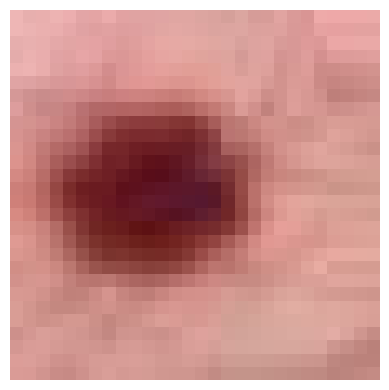

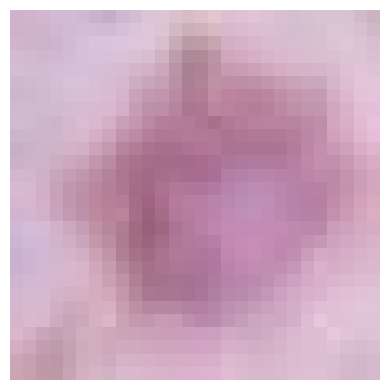

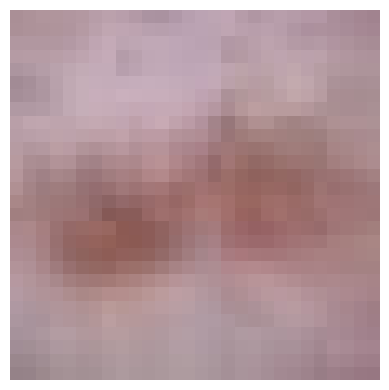

In [2]:
import torch
import mi_quantum.data as data
from mi_quantum.quantum.quanvolution import QuantumConv2D
from mi_quantum.quantum.vit import VisionTransformer
from mi_quantum.training import train_and_evaluate
import matplotlib.pyplot as plt
# Load data
notrans_train_dl, train_dl, val_dl, test_dl, shape = data.get_medmnist_dataloaders(
    pixel = exp_config['pixels'], data_flag='dermamnist', extra_tr_without_trans = True, batch_size=exp_config['B'], num_workers=4, pin_memory=True
)

save_path = "../QTransformer_Results_and_Datasets/selformer_results/current_results/grid_search0"

def view_image_from_torch(tensor, i):
    for j in range(i):
        image_np = tensor[j,...].permute(1, 2, 0).numpy()

        plt.figure(figsize=(15, 4))
        plt.imshow(image_np)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

def reshape_to_wide(tensor):
    if tensor.ndim != 5:
        raise ValueError(f"Input ndim must be 5 but got {tensor.ndim}")
    else:
        B, Q, C, H, W = tensor.shape
        return tensor.permute(0,2,3,1,4).reshape(B, C, H, W*Q)


selector = VisionTransformer(
    img_size=28, num_channels=3, num_classes=exp_config['num_classes'],
    patch_size=p1['1_patch_size'], hidden_size= 3* p1['1_patch_size']**2, num_heads=p1['1_num_head'], Attention_N = p1['1_Attention_N'],
    num_transformer_blocks=p1['1_num_transf'], attention_selection= p1['1_attention_selection'], selection_amount = p1['1_selection_amount'], special_cls = p1['1_special_cls'], 
    mlp_hidden_size=p1['1_mlp_size'], quantum_mlp = False, dropout = make_dropout( p1['1_dropout']) , channels_last=exp_config['channels_last'], quantum_classification = False,
    paralel = p1['1_paralel'], RD = p1['1_RD'], q_stride = p1['1_q_stride'], connectivity = 'chain'
)

selector.to(exp_config['device'])

test_auc_sel, test_acc_sel, val_auc_sel, val_acc_sel, train_auc_sel, _, params_sel = train_and_evaluate(
                        selector, train_dl, val_dl, test_dl, num_classes=exp_config['num_classes'],
                        learning_rate=p1['1_learning_rate'], num_epochs=exp_config['N1'], device=exp_config['device'], mapping=False,
                        res_folder=str(save_path), hidden_size=p1['1_hidden_size'], dropout= make_dropout( p1['1_dropout']),
                        num_heads=p1['1_num_head'], patch_size=p1['1_patch_size'], num_transf=p1['1_num_transf'],
                        mlp=p1['1_mlp_size'], wd=p1['1_weight_decay'], patience= p1['1_patience'], scheduler_factor=p1['1_scheduler_factor'], autoencoder=False,
                        augmentation_prob = p1['1_augmentation_prob'], val_train_pond=p1['1_val_train_pond']
                    )


first_batch = next(iter(test_dl))[0]

shape = first_batch.shape
B, C, H, W = shape
S, Q2, Q3, P = ( H // p1['1_patch_size'] )**2, 4, 9, p1['1_patch_size']
print(f"Shape of object: {shape}")
view_image_from_torch(first_batch, visualizing_n)


# 2x2 Kernel vs 3x3 Kernel

In [3]:
paddings = { 2 : { 'Up': 1, 'Down': 0, 'Left': 1, 'Right': 0 }, 3 : { 'Up': 1, 'Down': 1, 'Left': 1, 'Right': 1 } }
aux_patches, selected_indices = selector.get_patches_by_attention(first_batch.to(exp_config['device']))
aux_patches = aux_patches.to(exp_config['device'])
selected_indices = selected_indices.to(exp_config['device'])


# 2x2

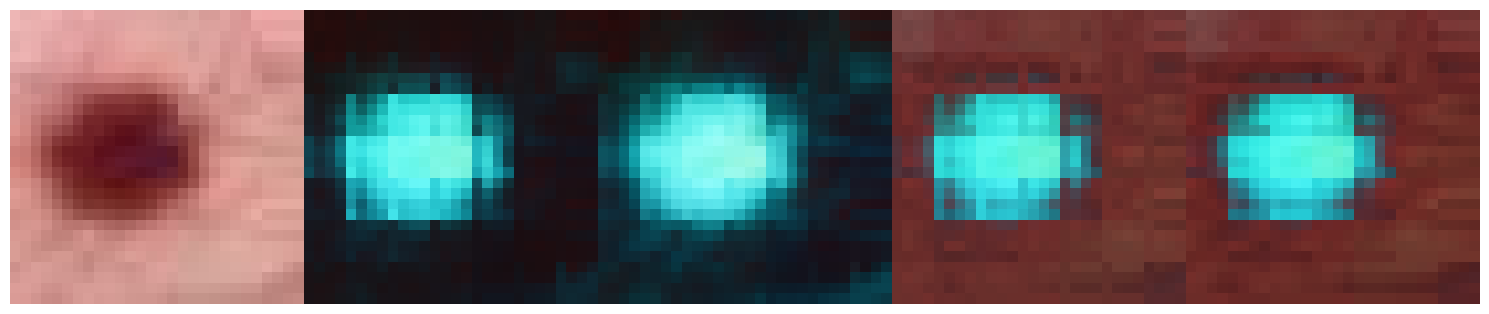

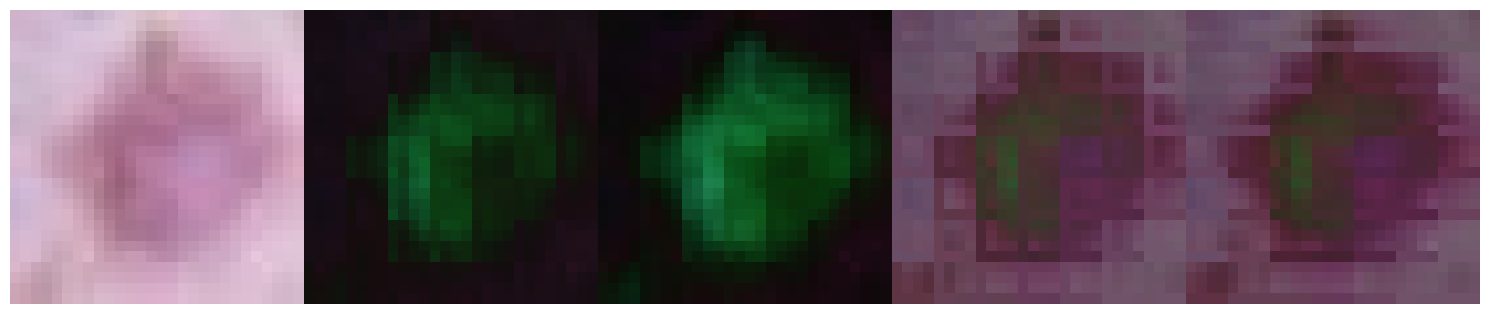

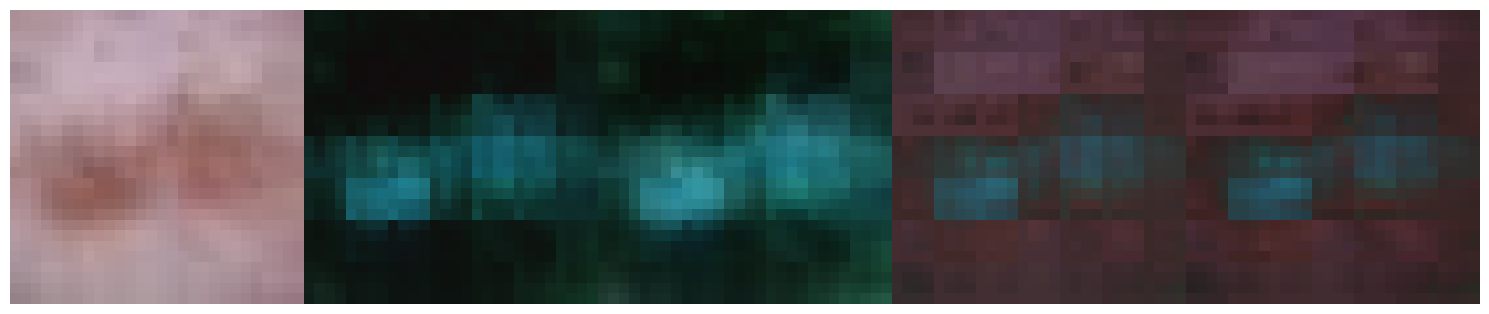

In [ ]:
Quanvolution2x2 = QuantumConv2D(kernel_size = 2, stride = 1, padding = paddings[2],
                             channels_out = list(range(4)), ancilla= 0, graph = 'star', entangle_method = 'CRX'
                            
).to(exp_config['device'])
aux_patches_processed2x2 = Quanvolution2x2(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size'])).reshape(B, Q2, p1['1_selection_amount'], C * P * P ).to(exp_config['device'])
flat_output2x2 = Quanvolution2x2(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size']))

# 2. Reshape to (Batch, Sequence, Q, Data)
# We respect that the output is a list of S patches, each containing Q variations
reshaped_output = flat_output2x2.reshape(B, p1['1_selection_amount'], Q2, C * P * P)
if concatenate_originals:
    reshaped_output = torch.cat([aux_patches.reshape(B,p1['1_selection_amount'], 1, C * P * P) ,reshaped_output], dim = 2)

# 3. Transpose Sequence and Q to get (Batch, Q, Sequence, Data)
aux_patches_processed2x2 = reshaped_output.transpose(1, 2).to(exp_config['device'])
reconstructed_processed2x2 = selector.reconstruct_image_from_patches(aux_patches_processed2x2, selected_indices, original_image_shape = shape).squeeze().detach().to('cpu')
view_image_from_torch(reshape_to_wide(reconstructed_processed2x2), visualizing_n)

# 3x3

In [5]:
Quanvolution3x3 = QuantumConv2D(kernel_size = 3, stride = 1, padding = paddings[3],
                             channels_out = list(range(9)),ancilla= p1['1_ancilla'], graph = 'chain',entangle_method = p1['1_entangle_method']
                            
).to(exp_config['device'])

aux_patches_processed3x3 = Quanvolution3x3(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size']))
aux_patches_processed3x3 = aux_patches_processed3x3.reshape(B, Q3, p1['1_selection_amount'], C * P * P ).to(exp_config['device'])
flat_output3x3 = Quanvolution3x3(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size']))

# 2. Reshape to (Batch, Sequence, Q, Data)
# We respect that the output is a list of S patches, each containing Q variations
reshaped_output = flat_output3x3.reshape(B, p1['1_selection_amount'], Q3, C * P * P)
if concatenate_originals:
    reshaped_output = torch.cat([aux_patches.reshape(B,p1['1_selection_amount'], 1, C * P * P) ,reshaped_output], dim = 2)

# 3. Transpose Sequence and Q to get (Batch, Q, Sequence, Data)
aux_patches_processed3x3 = reshaped_output.transpose(1, 2).to(exp_config['device'])
reconstructed_processed3x3 = selector.reconstruct_image_from_patches(aux_patches_processed3x3, selected_indices, original_image_shape = shape).squeeze().detach().to('cpu')
view_image_from_torch(reshape_to_wide(reconstructed_processed3x3), visualizing_n)

Please be ware that when ancilla is set to True channels_out must be [-1], but got [0, 1, 2, 3, 4, 5, 6, 7, 8].


KeyboardInterrupt: 

# Comparison between applying kernel patchwise or imagewise:

# 2x2 Kernel, Imagewise vs Patchwise

In [ ]:
# processed_first_batch2x2 = Quanvolution2x2(first_batch)

# if concatenate_originals:
#     processed_first_batch2x2 = torch.cat([first_batch, processed_first_batch2x2], dim = 1)

# processed_first_batch2x2 = processed_first_batch2x2.reshape(B, Q2+concatenate_originals, C, H, W).permute(0,2,3,1,4).reshape(B, C, H, (Q2+concatenate_originals)*W)

# print("Imagewise application of 2x2 kernel")
# view_image_from_torch(processed_first_batch2x2, visualizing_n)
# print("Patchwise application of 2x2 kernel")
# print(reconstructed_processed2x2.shape)
# view_image_from_torch(reshape_to_wide(reconstructed_processed2x2), visualizing_n)

# 3x3 Kernel, Imagewise vs Patchwise

In [ ]:
# processed_first_batch3x3 = Quanvolution3x3(first_batch)

# if concatenate_originals:
#     processed_first_batch3x3 = torch.cat([first_batch, processed_first_batch3x3], dim = 1)

# processed_first_batch3x3 = processed_first_batch3x3.reshape(B, Q3+concatenate_originals, C, H, W).permute(0,2,3,1,4).reshape(B, C, H, (Q3+concatenate_originals)*W)

# print("Imagewise application of 2x2 kernel")
# view_image_from_torch(processed_first_batch3x3, visualizing_n)
# print("Patchwise application of 3x3 kernel")
# view_image_from_torch(reshape_to_wide(reconstructed_processed3x3), visualizing_n)

# Data pipeline

In [ ]:
paddings = { 2 : { 'Up': 1, 'Down': 0, 'Left': 1, 'Right': 0 }, 3 : { 'Up': 1, 'Down': 1, 'Left': 1, 'Right': 1 } }
Kernels = { 
            'patchwise' :   QuantumConv2D(
                                kernel_size = 2,
                                stride = 1,
                                padding = paddings[2],
                                channels_out = list(range(4)),
                                ancilla= p1['1_ancilla'],
                                graph = 'star',
                                entangle_method = p1['1_entangle_method']
                            )
            }

Latents = data.preprocess_and_save(
    B = exp_config['B'],
    DataLoaders = [notrans_train_dl, val_dl, test_dl],
    kernels = Kernels,
    save_path = f"../QTransformer_Results_and_Datasets/selformer_results/visualize/quantum_datasets",
    mode = 'by_selected_patches',
    model1 = selector,
    p1 = p1,
    num_channels = C,
    flatten_extra_channels = p1['1_flatten_extra_channels'],
    device = exp_config['device'],
    flatten = not exp_config['augmenting'], 
    concatenate_original = exp_config.get('concatenate_original', False)
)


Running in 'by_selected_patches' mode.
Reshape config: Flatten extra channels? False


Processing train split:   4%|▎         | 1/28 [00:02<01:17,  2.88s/it]


--- Debug Shapes (q_idx: 0, name: patchwise, split: train, batch 0) ---
Shape out of q-convolution (aux_patch_outs): torch.Size([256, 5, 49, 48])
Shape after reshape (processed_data batch): torch.Size([256, 245, 48])
Stored item shape (last_processed_shapes): torch.Size([245, 48])
--------------------------------------------------


Processing train split: 100%|██████████| 28/28 [01:16<00:00,  2.72s/it]


Hypershape for train, kernels patchwise (idx 0): torch.Size([7007, 245, 48]), Labels shape: torch.Size([7007, 1])


Processing validation split: 100%|██████████| 4/4 [00:10<00:00,  2.75s/it]


Hypershape for validation, kernels patchwise (idx 0): torch.Size([1003, 245, 48]), Labels shape: torch.Size([1003, 1])


Processing test split: 100%|██████████| 8/8 [00:21<00:00,  2.73s/it]


Hypershape for test, kernels patchwise (idx 0): torch.Size([2005, 245, 48]), Labels shape: torch.Size([2005, 1])
Saved quantum datasets for kernels 'patchwise' at ../QTransformer_Results_and_Datasets/selformer_results/visualize/quantum_datasets


In [ ]:
latent_train_dl, latent_val_dl, latent_test_dl, shape_latent = Latents['patchwise']

# Load data in case it is already generated

In [ ]:
latent_train = torch.load("../QTransformer_Results_and_Datasets/selformer_results/visualize/quantum_datasets/quantum_train_datasetpatchwise.pt", weights_only= True)
latent_val = torch.load("../QTransformer_Results_and_Datasets/selformer_results/visualize/quantum_datasets/quantum_val_datasetpatchwise.pt", weights_only= True)
latent_test = torch.load("../QTransformer_Results_and_Datasets/selformer_results/visualize/quantum_datasets/quantum_test_datasetpatchwise.pt", weights_only= True)

latent_train_dl, latent_val_dl, latent_test_dl, shape_latent = data.create_dataloaders(
    None, 
    batch_size=exp_config['B'], 
    channels_last=False, 
    shuffle=False, 
    tensors=[latent_train, latent_val, latent_test],
    # Add this line to disable transforms:
    transforms={'train': None, 'val': None, 'test': None} 
)

# Reconstruct first batch to see the behaviour of the reconstructor

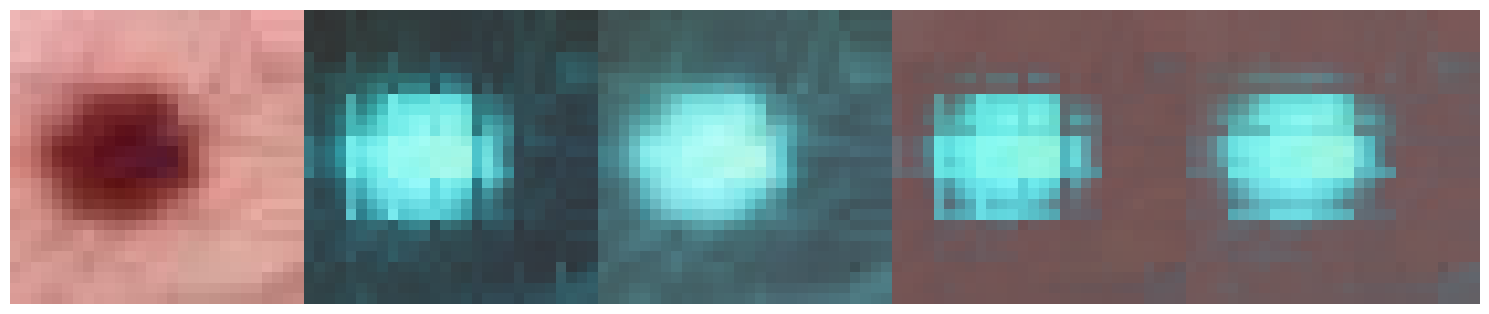

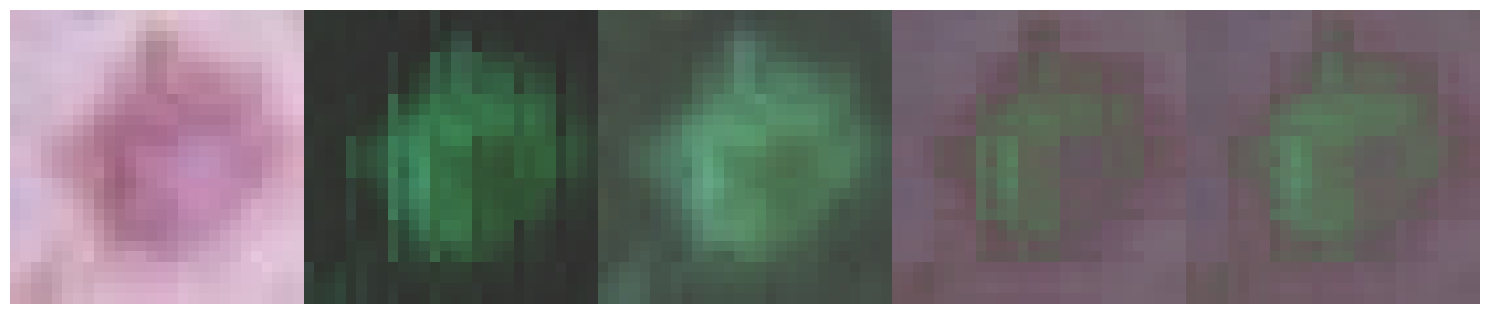

In [ ]:
first_batch_latent = next(iter(latent_test_dl))[0].reshape(B, Q2 + 1, S, C*P*P)                     # Reshape so that it matches reconstructor
first_batch = next(iter(test_dl))[0].to(exp_config['device'])                                       # Ensure it is on the same device
selector.to(exp_config['device'])                                                                   # Ensure it is on the same device

selected_patches, selected_indices = selector.get_patches_by_attention(first_batch)                 # Compute selected patches and indices
reconstructed_processed2x2 = selector.reconstruct_image_from_patches(first_batch_latent, selected_indices, original_image_shape = shape).squeeze().detach().to('cpu')
x2towide = reshape_to_wide(reconstructed_processed2x2)
view_image_from_torch(x2towide, 2)

In [ ]:
print(selected_patches.shape, selected_indices.shape)

torch.Size([256, 49, 48]) torch.Size([256, 49])


In [ ]:
classifier1 = VisionTransformer(
                                    img_size = shape[-1], num_channels= 3, num_classes=exp_config['num_classes'],
                                    patch_size=p2['patch_size'], hidden_size= shape_latent[-1], num_heads=p2['num_head'], Attention_N = p2['Attention_N'],
                                    num_transformer_blocks=p2['num_transf'], attention_selection= p2['attention_selection'], special_cls = p2['special_cls'], 
                                    mlp_hidden_size=p2['mlp_size'], quantum_mlp = False, dropout = make_dropout(p2['dropout']), channels_last=exp_config['channels_last'], quantum_classification = False,
                                    paralel = p2['paralel'] , selection_amount = p2['selection_amount'], RD = p2['RD'], q_stride = p2['q_stride'], connectivity = 'chain', patch_embedding_required = 'flatten' if exp_config['augmenting'] else 'false'
                                )
print(classifier1.q_lr)
classifier2 = VisionTransformer(
                                    img_size = shape[-1], num_channels= 3, num_classes=exp_config['num_classes'],
                                    patch_size=p2['patch_size'], hidden_size= shape_latent[-1], num_heads=p2['num_head'], Attention_N = p2['Attention_N'],
                                    num_transformer_blocks=p2['num_transf'], attention_selection= p2['attention_selection'], special_cls = p2['special_cls'], 
                                    mlp_hidden_size=p2['mlp_size'], quantum_mlp = False, dropout = make_dropout(p2['dropout']), channels_last=exp_config['channels_last'], quantum_classification = False,
                                    paralel = p2['paralel'] , selection_amount = p2['selection_amount'], RD = p2['RD'], q_stride = p2['q_stride'], connectivity = 'chain', patch_embedding_required = 'flatten' if exp_config['augmenting'] else 'false'
                                )
classifier3 = VisionTransformer(
                                    img_size = shape[-1], num_channels= 3, num_classes=exp_config['num_classes'],
                                    patch_size=p2['patch_size'], hidden_size= shape_latent[-1], num_heads=p2['num_head'], Attention_N = p2['Attention_N'],
                                    num_transformer_blocks=p2['num_transf'], attention_selection= p2['attention_selection'], special_cls = p2['special_cls'], 
                                    mlp_hidden_size=p2['mlp_size'], quantum_mlp = False, dropout = make_dropout(p2['dropout']), channels_last=exp_config['channels_last'], quantum_classification = False,
                                    paralel = p2['paralel'] , selection_amount = p2['selection_amount'], RD = p2['RD'], q_stride = p2['q_stride'], connectivity = 'chain', patch_embedding_required = 'flatten' if exp_config['augmenting'] else 'false'
                                )
classifier4 = VisionTransformer(
                                    img_size = shape[-1], num_channels= 3, num_classes=exp_config['num_classes'],
                                    patch_size=p2['patch_size'], hidden_size= shape_latent[-1], num_heads=p2['num_head'], Attention_N = p2['Attention_N'],
                                    num_transformer_blocks=p2['num_transf'], attention_selection= p2['attention_selection'], special_cls = p2['special_cls'], 
                                    mlp_hidden_size=p2['mlp_size'], quantum_mlp = False, dropout = make_dropout(p2['dropout']), channels_last=exp_config['channels_last'], quantum_classification = False,
                                    paralel = p2['paralel'] , selection_amount = p2['selection_amount'], RD = p2['RD'], q_stride = p2['q_stride'], connectivity = 'chain', patch_embedding_required = 'flatten' if exp_config['augmenting'] else 'false'
                                )
# Train second model
test_auc, test_acc, val_auc, val_acc, train_auc, train_acc, params = train_and_evaluate(
    classifier1, latent_train_dl, latent_val_dl, latent_test_dl, num_classes = exp_config['num_classes'],
    learning_rate=p2['learning_rate'], num_epochs=exp_config['N2'], device=exp_config['device'], mapping=False,
    res_folder=str(save_path), hidden_size=p2['hidden_size'], dropout=make_dropout(p2['dropout']),
    num_heads=p2['num_head'], patch_size=p2['patch_size'], num_transf=p2['num_transf'],
    mlp=p2['mlp_size'], wd=p2['weight_decay'], patience= p2['patience'], scheduler_factor=p2['scheduler_factor'], 
    autoencoder=False, augmentation_prob = p2['augmentation_prob'], val_train_pond=p2['val_train_pond']
)

# Train second model
test_auc, test_acc, val_auc, val_acc, train_auc, train_acc, params = train_and_evaluate(
    classifier2, latent_train_dl, latent_val_dl, latent_test_dl, num_classes = exp_config['num_classes'],
    learning_rate=p2['learning_rate'], num_epochs=exp_config['N2'], device=exp_config['device'], mapping=False,
    res_folder=str(save_path), hidden_size=p2['hidden_size'], dropout=make_dropout(p2['dropout']),
    num_heads=p2['num_head'], patch_size=p2['patch_size'], num_transf=p2['num_transf'],
    mlp=p2['mlp_size'], wd=p2['weight_decay'], patience= p2['patience'], scheduler_factor=p2['scheduler_factor'], 
    autoencoder=False, augmentation_prob = p2['augmentation_prob'], val_train_pond=p2['val_train_pond']
)

# Train second model
test_auc, test_acc, val_auc, val_acc, train_auc, train_acc, params = train_and_evaluate(
    classifier3, latent_train_dl, latent_val_dl, latent_test_dl, num_classes = exp_config['num_classes'],
    learning_rate=p2['learning_rate'], num_epochs=exp_config['N2'], device=exp_config['device'], mapping=False,
    res_folder=str(save_path), hidden_size=p2['hidden_size'], dropout=make_dropout(p2['dropout']),
    num_heads=p2['num_head'], patch_size=p2['patch_size'], num_transf=p2['num_transf'],
    mlp=p2['mlp_size'], wd=p2['weight_decay'], patience= p2['patience'], scheduler_factor=p2['scheduler_factor'], 
    autoencoder=False, augmentation_prob = p2['augmentation_prob'], val_train_pond=p2['val_train_pond']
)

# Train second model
test_auc, test_acc, val_auc, val_acc, train_auc, train_acc, params = train_and_evaluate(
    classifier4, latent_train_dl, latent_val_dl, latent_test_dl, num_classes = exp_config['num_classes'],
    learning_rate=p2['learning_rate'], num_epochs=exp_config['N2'], device=exp_config['device'], mapping=False,
    res_folder=str(save_path), hidden_size=p2['hidden_size'], dropout=make_dropout(p2['dropout']),
    num_heads=p2['num_head'], patch_size=p2['patch_size'], num_transf=p2['num_transf'],
    mlp=p2['mlp_size'], wd=p2['weight_decay'], patience= p2['patience'], scheduler_factor=p2['scheduler_factor'], 
    autoencoder=False, augmentation_prob = p2['augmentation_prob'], val_train_pond=p2['val_train_pond']
)

Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
49
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 he

Epoch   1/30:   0%|     | 0/28 [00:00<?, ?batch/s]

Epoch  30/30: 100%|█████| 28/28 [00:02<00:00,  9.84batch/s, Val Loss=0.761, Valid AUC=90.10%, Train AUC=88.58 ||| Valid ACC=71.39%, Train ACC=70.87%]


TOTAL TIME = 85.61s
BEST AUC TRAIN = 88.70% AT EPOCH 29
BEST AUC VAL = 90.10% AT EPOCH 30
TEST AUC: 88.31%, TEST ACC: 70.12%
Number of trainable parameters: 46283


Epoch  30/30: 100%|█████| 28/28 [00:02<00:00,  9.82batch/s, Val Loss=0.783, Valid AUC=89.63%, Train AUC=87.88 ||| Valid ACC=69.89%, Train ACC=70.44%]


TOTAL TIME = 85.68s
BEST AUC TRAIN = 87.88% AT EPOCH 30
BEST AUC VAL = 89.87% AT EPOCH 29
TEST AUC: 88.09%, TEST ACC: 69.33%
Number of trainable parameters: 46283


Epoch  30/30: 100%|█████| 28/28 [00:02<00:00,  9.82batch/s, Val Loss=0.789, Valid AUC=88.98%, Train AUC=87.92 ||| Valid ACC=69.69%, Train ACC=70.59%]


TOTAL TIME = 85.68s
BEST AUC TRAIN = 87.92% AT EPOCH 30
BEST AUC VAL = 89.24% AT EPOCH 28
TEST AUC: 87.86%, TEST ACC: 69.48%
Number of trainable parameters: 46283


Epoch  30/30: 100%|█████| 28/28 [00:02<00:00,  9.83batch/s, Val Loss=0.773, Valid AUC=89.44%, Train AUC=88.82 ||| Valid ACC=71.78%, Train ACC=71.19%]


TOTAL TIME = 85.66s
BEST AUC TRAIN = 88.82% AT EPOCH 30
BEST AUC VAL = 90.06% AT EPOCH 28
TEST AUC: 88.32%, TEST ACC: 70.07%


In [ ]:
def rank_patches_by_attention(attn: torch.Tensor) -> torch.Tensor:
            """
            Ranks image patches by the total attention they receive.

            """
            # Average over heads: (B, T, T)
            attn_mean = attn.mean(dim=1)

            # Total attention received by each token: sum over the source positions (axis=-2)
            # attention_received[b, j] = sum over i of attn[b, i, j]
            attention_received = attn_mean.sum(dim=1)  # shape: (B, T)

            # Sort patches by total attention received, descending
            sorted_indices = attention_received.argsort(dim=1, descending=True)  # shape: (B, T)

            return sorted_indices

In [ ]:
import torch
import matplotlib.pyplot as plt

Q = 5

def view_selection_distribution(classifier, splits = ['test']):

    dataloaders = {'train': latent_train_dl, 'val' : latent_val_dl, 'test' : latent_test_dl}
    splits_dl = [dataloaders[split] for split in splits if split in dataloaders]

    with torch.no_grad():
        for i, dl in enumerate(splits_dl):
            
            quantile_accumulators = torch.zeros(Q, device=exp_config['device'])
            total_images_seen = 0
            
            print(f"Processing Split {i}...")

            for imgs, labels, idxs in dl:
                imgs = imgs.to(exp_config['device'])
                
                _ , attention_for_images = classifier.transformer_blocks[0][0].attn(imgs)
                indices_by_attention = rank_patches_by_attention(attention_for_images)
                
                # Select the specific column/indices we care about once
                # Assuming p1['1_selection_amount'] is the number of columns to look at
                selection = indices_by_attention[:, :p1['1_selection_amount']]
                
                for j in range(Q):
                    lower_bound = j * p1['1_selection_amount']
                    upper_bound = (j + 1) * p1['1_selection_amount']
                    
                    # FIX 1: Use '<' for upper bound to avoid double counting overlaps
                    mask = (selection < upper_bound) & (selection >= lower_bound)
                    
                    quantile_accumulators[j] += torch.sum(mask)
                
                total_images_seen += imgs.shape[0]

            # FIX 2: Removed 'Q' from the denominator
            # Denominator = (Number of images) * (Number of patches selected per image)
            denominator = total_images_seen * p1['1_selection_amount']
            
            final_percentages = (quantile_accumulators / denominator).cpu().numpy()

            # Verification: Check if it sums to ~1
            print(f"Sum of bars: {final_percentages.sum():.4f}")

            plt.figure(figsize=(10, 6))
            plt.bar(x=range(Q), height=final_percentages)
            plt.title(f"Split: {["Train", "Validation", "Test"][i]} Quantum Distribution")
            plt.show()

Processing Split 0...
Sum of bars: 1.0000


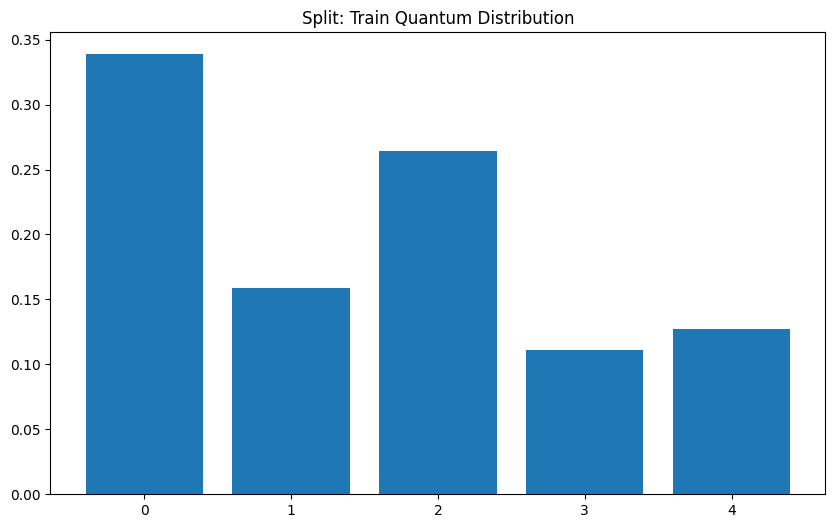

Processing Split 0...
Sum of bars: 1.0000


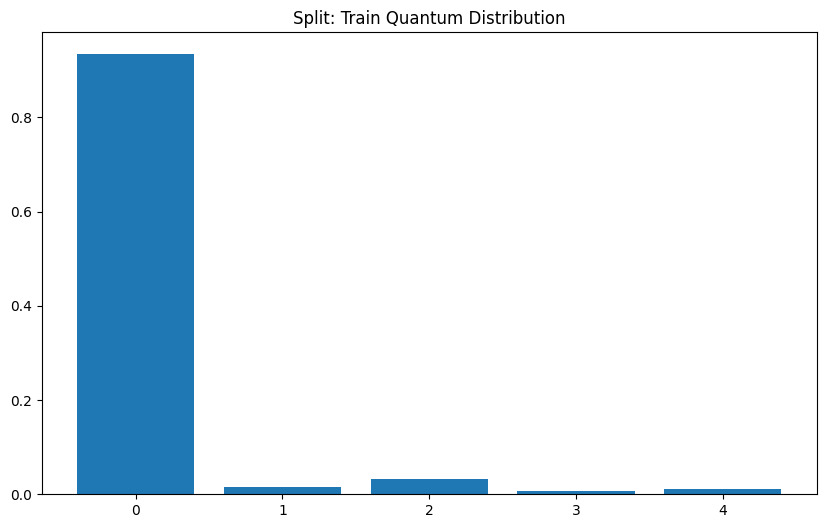

Processing Split 0...
Sum of bars: 1.0000


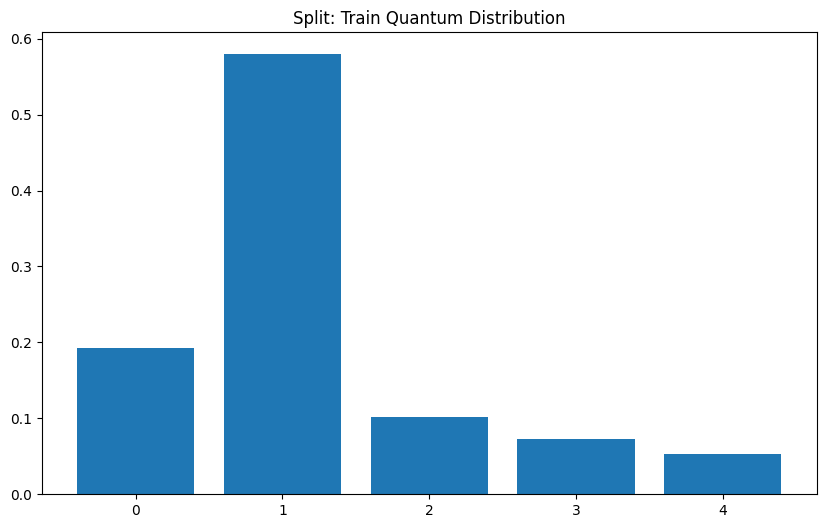

Processing Split 0...
Sum of bars: 1.0000


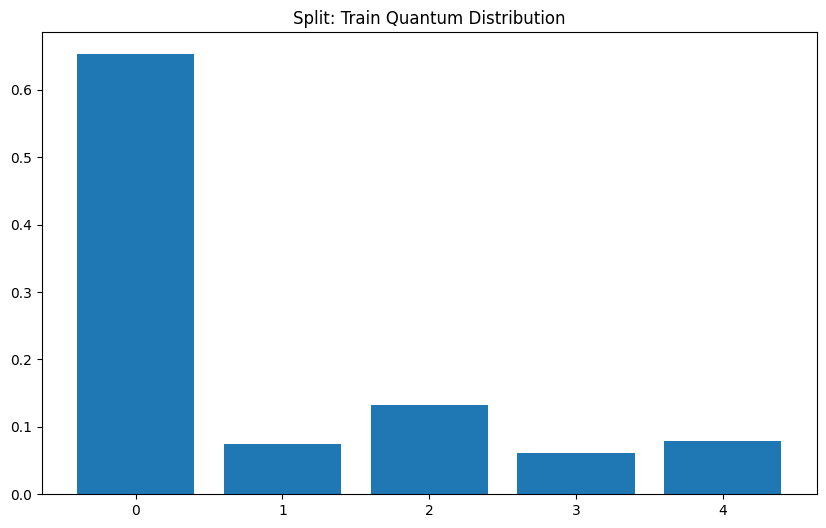

In [ ]:
view_selection_distribution(classifier1)
view_selection_distribution(classifier2)
view_selection_distribution(classifier3)
view_selection_distribution(classifier4)

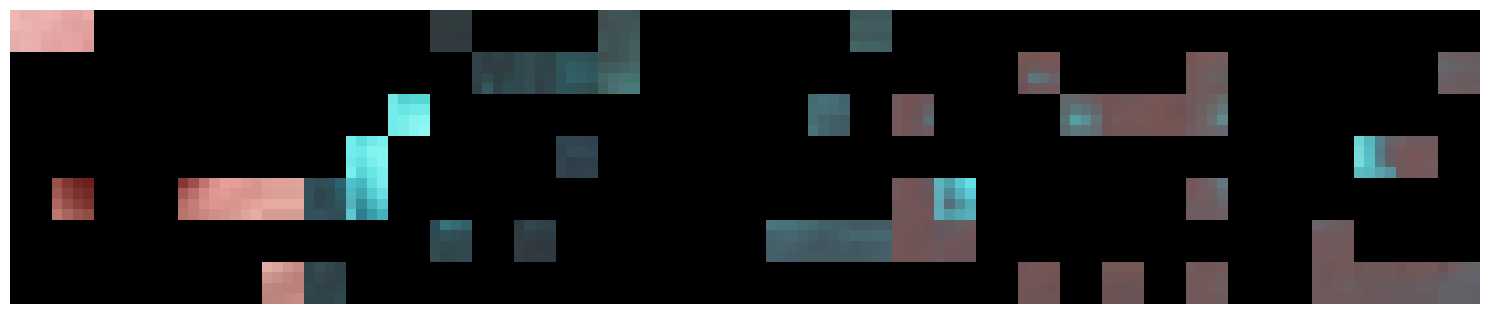

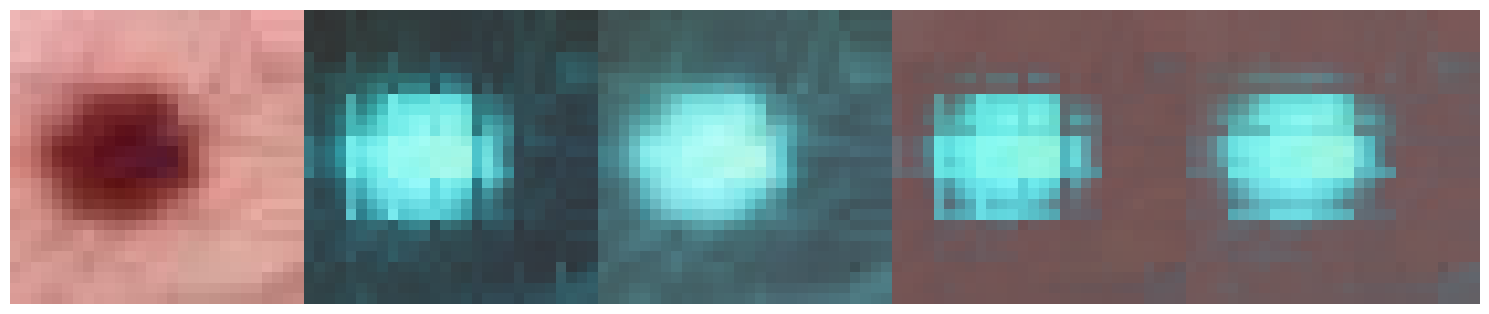

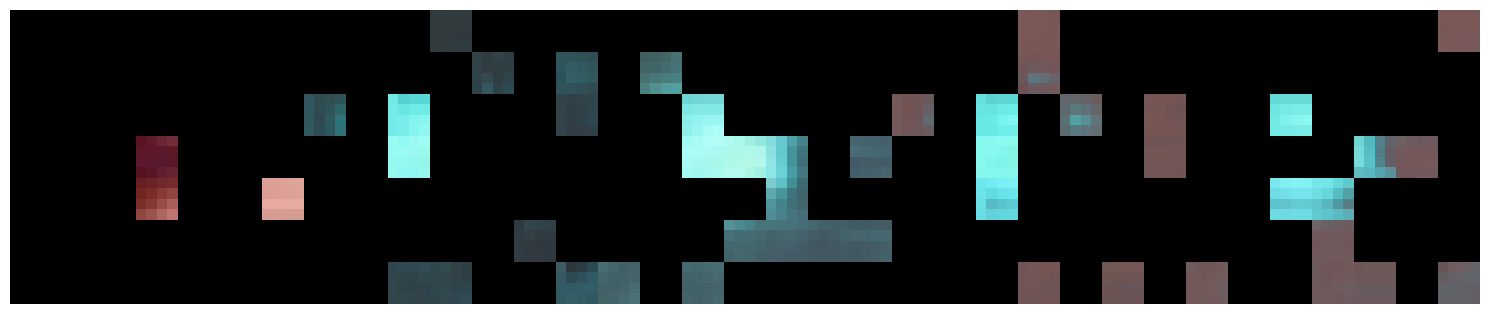

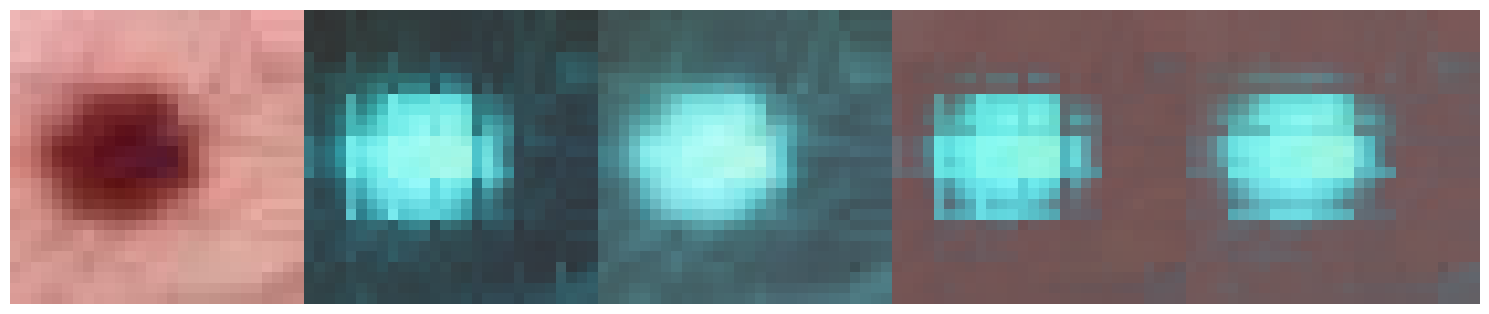

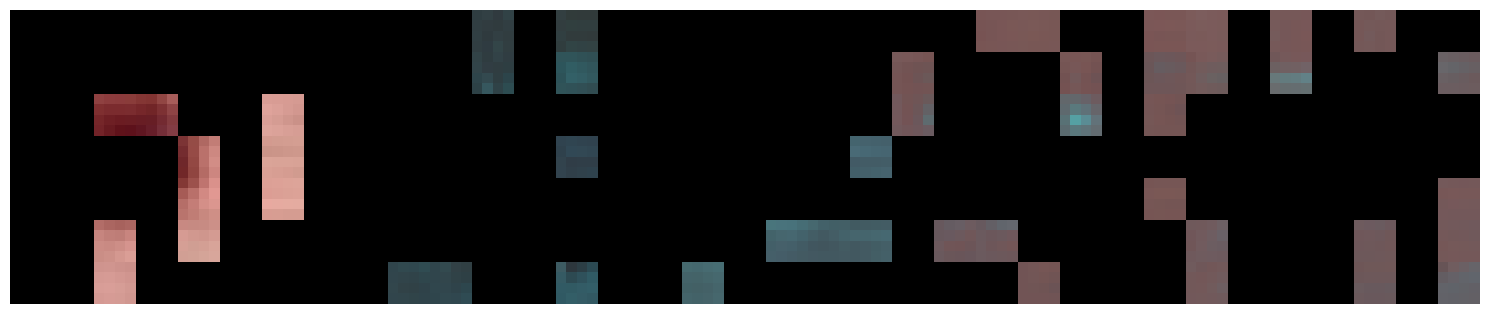

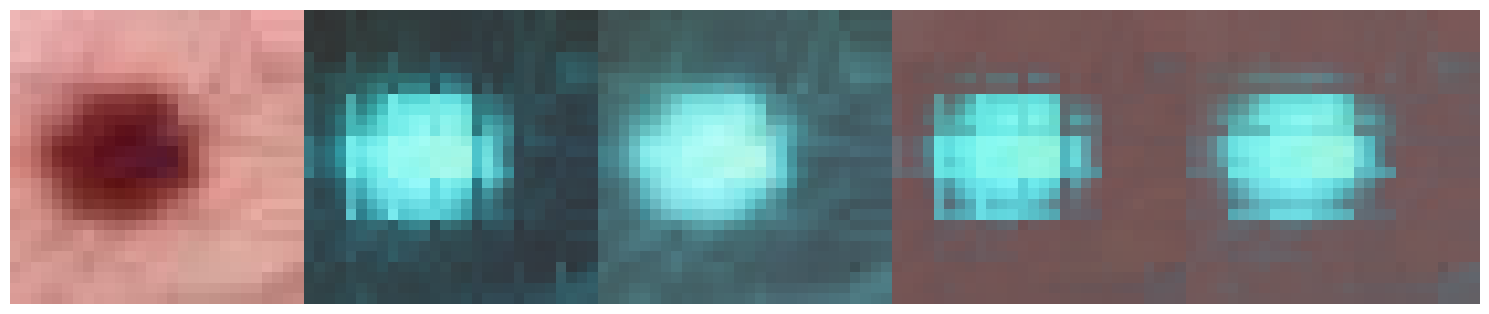

In [ ]:
classifier1.patch_embedding_required = "true"
classifier2.patch_embedding_required = "true"
classifier3.patch_embedding_required = "true"
x2towide = x2towide.to(exp_config['device'])
selected_patches_wide, selected_indices_wide = classifier1.get_patches_by_attention(x2towide)
reconstructed_wide1 = classifier1.reconstruct_image_from_patches(selected_patches_wide.unsqueeze(1), selected_indices_wide, original_image_shape= (3, 28, 28*5))
selected_patches_wide, selected_indices_wide = classifier2.get_patches_by_attention(x2towide)
reconstructed_wide2 = classifier2.reconstruct_image_from_patches(selected_patches_wide.unsqueeze(1), selected_indices_wide, original_image_shape= (3, 28, 28*5))
selected_patches_wide, selected_indices_wide = classifier3.get_patches_by_attention(x2towide)
reconstructed_wide3 = classifier3.reconstruct_image_from_patches(selected_patches_wide.unsqueeze(1), selected_indices_wide, original_image_shape= (3, 28, 28*5))
view_image_from_torch(reconstructed_wide1.squeeze().cpu(), 1)
view_image_from_torch(x2towide.cpu(), 1)
view_image_from_torch(reconstructed_wide2.squeeze().cpu(), 1)
view_image_from_torch(x2towide.cpu(), 1)
view_image_from_torch(reconstructed_wide3.squeeze().cpu(), 1)
view_image_from_torch(x2towide.cpu(), 1)

In [ ]:
def get_patches_by_attention(model, x, paralel_branch = 0):
        """ 
        x: (batch_size, num_channels, img_size, img_size)
        ...
        returns: 
            gathered_patches: (batch_size, q_lr, hidden_size)
            sel_patch_indices_0_based: (batch_size, q_lr)
        """
        # x.shape = (batch_size, num_patches, hidden_size)
        x_embedded = model.patch_embed_sample(x) 
        
        # Positional embedding
        if  x_embedded.shape[1:] == model.pos_embedding.shape[1:]:
            x_with_pos = x_embedded + model.pos_embedding[:,1:,:].to(x_embedded.device) 

        elif x_embedded.shape[1] % (model.pos_embedding.shape[1] - 1)== 0:
            x_with_pos = x_embedded + model.pos_embedding[:,1:,:].repeat(1, x_embedded.shape[1] // (model.pos_embedding.shape[1]-1), 1) # [B, S, D]

        else:
            print(f"Warning, skipping positional_embedding as shapes of [input tensor,cls_token]: {x_embedded.shape} and pos_embedding {model.pos_embedding.shape} don't match")
            x_with_pos = x_embedded

        # CLS token
        # We want to add the cls token so that it takes part in the attention calculation
        cls_token = (model.cls_token + model.pos_embedding[:,0,:]).expand(x_with_pos.shape[0], -1, -1).to(x_with_pos.device)
        x_with_cls_and_pos = torch.cat((cls_token, x_with_pos), dim=1) 
        # x.shape = (batch_size, num_steps, hidden_size)
   
        # Attention block
        attn_input = model.transformer_blocks[paralel_branch][0].attn_norm(x_with_cls_and_pos)
        # Note: Your original code assumes attn returns (output, map)
        _, attn_map = model.transformer_blocks[paralel_branch][0].attn(attn_input)

        # Rank patches by attention
        attn_indices = rank_patches_by_attention(attn_map)

        print(model.q_lr)
        # Remove CLS token (index 0) from selection and select top q_lr
        sel_indices_with_cls_offset = torch.stack( [ attn_indices[i][ attn_indices[i] != 0 ][:model.q_lr] for i in range(attn_indices.size(0)) ])

 
        # Convert to 0-based patch indices (by subtracting 1 for the CLS token)
        # This is the index relative to the *original* patch list (0 to num_patches-1)
        sel_patch_indices_0_based = sel_indices_with_cls_offset - 1

        # Gather the embedded patches
        gathered_patches = x_embedded.gather(1, sel_patch_indices_0_based.unsqueeze(-1).expand(-1, -1, x_embedded.size(-1)) ) # Shape: (batch_size, q_lr, hidden_size)

        
        return gathered_patches, sel_patch_indices_0_based